In [1]:
from datetime import datetime
import pickle
import os
from multiprocessing import Pool

import numpy as np
import pandas as pd
import lingam
from scipy.stats import kendalltau

import matplotlib.pyplot as plt

np.random.seed(0)

## DAGと誤差変数の生成

In [2]:
# 通常のランダム生成
def make_dag_and_errors(n_nodes, sample_size, J=3, weight=0.5):
    dag = np.zeros((n_nodes, n_nodes))
    errors = None
    
    # For each node v
    for v in range(n_nodes):        
        #  select the number of parents
        num_pa = np.random.choice(np.arange(min(n_nodes, J)))

        if v - 1 >= 0:
            # We include edge (v − 1, v) to ensure that the ordering is unique
            dag[v, v - 1] = np.random.choice([-1, 1]) * np.random.uniform(weight, 1)

        # The remaining parents are selected uniformly from [v − 2]
        candidates = np.arange(v - 1)
        if len(candidates) == 0:
            continue

        # num_paは最低3あるが、例えば2列目の変数の候補は[0]しかない。(1は順序を一意に保つために使う)
        # そのためlen(candidate)との大小関係もチェックが要る。
        pa = np.random.choice(candidates, size=min(num_pa, len(candidates)), replace=False)

        # the corresponding edge weights are set to +-1/5
        dag[v, pa] = np.random.choice([-1/5, 1/5], size=len(pa))

    # The n error terms for variable v are generated by selecting σv ∼ unif(.8, 1) drawing εvi ∼ σvunif(−√3,√3).
    v = np.random.uniform(0.8, 1, size=n_nodes)
    errors = v * np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))

    return dag, errors

# ハブ付き
def make_dag_and_errors_hub(n_nodes, sample_size, J=2):
    # HubGraph
    dag, _ = make_dag_and_errors(n_nodes, sample_size, J=J, weight=0.65)

    # add hubs
    # 非hubノードはいずれかのハブからのエッジを受けること。対角直下は決まっているので手をださないこと。
    for v in np.arange(3, n_nodes):
        # ハブの選択と係数の作成
        coefs = np.zeros(3)
        
        if v == 3:
            # 変数3のみ特別処理。変数2との接続は強制なのでそれ以外から選ぶ。
            index = np.random.choice([0, 1])
        else:
            index = np.random.choice([0, 1, 2])
        
        coefs[index] = np.random.choice([-1/5, 1/5])

        # すでに係数が設定してあれば、そちらを優先する。coefはdag側が0である部分のみ非ゼロになる。
        filter_ = ~np.isclose(dag[v, :3], 0)
        coefs[filter_] = 0
        
        # フィルタしているので足して設定する
        dag[v, :3] += coefs

    # disturbances
    v = np.random.uniform(0.8, 1, size=n_nodes)
    errors = v * np.random.uniform(-np.sqrt(3), np.sqrt(3), size=(sample_size, n_nodes))
    
    return dag, errors

### ランダム生成の例
対角の下が強め、ランダムなエッジは小さめになる。

In [3]:
dag, errors = make_dag_and_errors(8, 1000)
pd.DataFrame(dag).style.background_gradient(vmin=-1, vmax=1)

,0,1,2,3,4,5,6,7
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.801382,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-0.200000,0.822947,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,-0.200000,0.200000,-0.981831,0.000000,0.000000,0.000000,0.000000,0.000000
4,-0.200000,0.000000,0.200000,-0.696392,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.684121,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,-0.736804,0.000000,0.000000
7,0.000000,0.000000,-0.200000,0.000000,-0.200000,0.000000,0.819961,0.000000


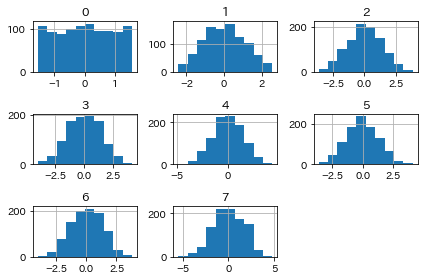

In [4]:
X = errors @ np.linalg.pinv(np.eye(len(dag)) - dag).T
pd.DataFrame(X).hist()
plt.tight_layout()
plt.show()

### ハブつきランダム生成の例

ノード0, 1, 2がハブとなり多くの変数の親となるため、0, 1, 2列は非ゼロの値がいくつか格納される。

In [5]:
dag, errors = make_dag_and_errors_hub(8, 1000)
pd.DataFrame(dag).style.background_gradient(vmin=-1, vmax=1)

,0,1,2,3,4,5,6,7
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.992674,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.200000,0.758404,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,-0.200000,0.994157,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.200000,0.000000,-0.200000,-0.761634,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.200000,-0.200000,0.000000,-0.805072,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.200000,0.000000,0.000000,0.900371,0.000000,0.000000
7,-0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.740583,0.000000


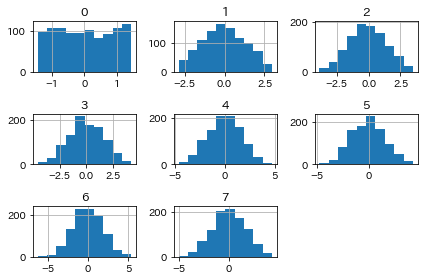

In [6]:
X = errors @ np.linalg.pinv(np.eye(len(dag)) - dag).T
pd.DataFrame(X).hist()
plt.tight_layout()
plt.show()

## 検証関数

In [7]:
def n_list_func_impl(p):
    return [10 * p, 50 * p]

def test_impl(args):
    p, n, i, seed, disable_direct, make_func = args
    
    np.random.seed(seed)
    
    true_order = np.arange(p)

    dag, errors = make_func(p, n)
    X = (np.linalg.pinv(np.eye(p) - dag) @ errors.T).T

    # evals high_im
    high_d_start = datetime.now()

    # XXX:
    #high_d_model = lingam.HighDimDirectLiNGAM()
    high_d_model = lingam.DirectLiNGAM()
    high_d_model.fit(X)

    elapse_high_d = (datetime.now() - high_d_start).total_seconds()

    eval_high_d = kendalltau(high_d_model.causal_order_, true_order).statistic

    # evals normal
    if disable_direct:
        eval_normal = None
        elapse_normal = None
    else:
        normal_start = datetime.now()
        
        normal_model = lingam.DirectLiNGAM()
        normal_model.fit(X)
        
        elapse_normal = (datetime.now() - normal_start).total_seconds()

        eval_normal = kendalltau(normal_model.causal_order_, true_order).statistic
        
    print(f"\r{i:8d}", end="")

    return i, eval_high_d, elapse_high_d, eval_normal, elapse_normal
            
def run_test(p_list=None, n_list_func=None, loop_num=500, make_func=None, disable_direct=False, n_cores=24):
    if p_list is None:
        p_list = np.arange(5, 25, 5, dtype=int)

    if n_list_func is None:
        n_list_func = n_list_func_impl

    if make_func is None:
        make_func = make_dag_and_errors
    
    results = {}
    
    for p in p_list:
        for n in n_list_func(p):
            print(f"+p={p:4d}, n={n:4d}")
            
            start = datetime.now()
            
            # テスト実行の引数を辞書に詰め込む
            seeds = np.random.randint(0, high=0xFFFFFFFF, size=loop_num)
            args = {(p, n, i, seed, disable_direct, make_func) for i, seed in enumerate(seeds)}
            
            # マルチプロセスの有効無効
            if n_cores > 0:
                with Pool(n_cores) as pool:
                    result = pool.map(test_impl, args)
            else:
                result = []
                for arg in args:
                    result.append(test_impl(arg))
                
            result = sorted(result, key=lambda e: e[0])
            indices, eval_high_d, elapse_high_d, eval_normal, elapse_normal = np.array(result).T
            
            results[(n, p)] = {
                "high_d": eval_high_d,
                "normal": eval_normal,
                "elapse_high_d": elapse_high_d,
                "elapse_normal": elapse_normal,
            }
            
            elapse = (datetime.now() - start).total_seconds()
            
            print(f"\r-p={p:4d}, n={n:4d}, elapse={elapse:.2f}sec")

    max_p = max(p_list)
    max_n = max(n_list_func(max_p))
    fname = datetime.now().strftime('%Y%m%d%H%M%S') + f"_{max_p}_{max_n}_{loop_num}.bin"

    with open(fname, "wb") as f:
        pickle.dump(results, f)
    print("saved:", fname)
        
    return results

## 低次元時の検証

In [8]:
if True:
    results = run_test(
        # XXX:
        #loop_num=500,
        loop_num=8,
        n_cores=8,
        p_list = np.arange(5, 25, 5, dtype=int),
        n_list_func=n_list_func_impl
    )
else:
    # run_test後に得られるpickleを読み込む場合はこちら
    with open("20240614193139_20_1000_500.bin", "rb") as f:
        results = pickle.load(f)

+p=   5, n=  50
-p=   5, n=  50, elapse=0.14sec
+p=   5, n= 250
-p=   5, n= 250, elapse=0.16sec
+p=  10, n= 100
-p=  10, n= 100, elapse=0.52sec
+p=  10, n= 500
-p=  10, n= 500, elapse=0.54sec
+p=  15, n= 150
-p=  15, n= 150, elapse=1.49sec
+p=  15, n= 750
-p=  15, n= 750, elapse=1.67sec
+p=  20, n= 200
-p=  20, n= 200, elapse=3.41sec
+p=  20, n=1000
-p=  20, n=1000, elapse=4.07sec
saved: 20240619190911_20_1000_8.bin


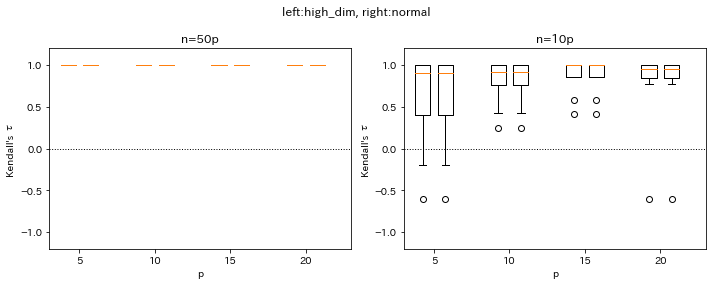

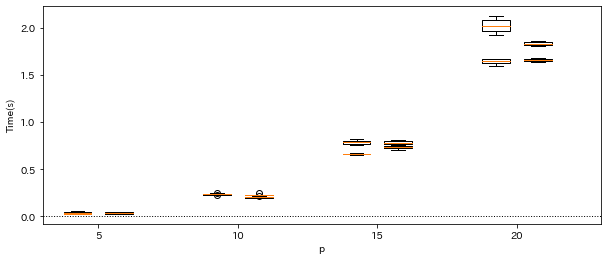

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for (n, p), evals in results.items():
    ax = axes[0] if n / p == 50.0 else axes[1]
    
    ax.boxplot(
        evals["high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    ax.boxplot(
        evals["normal"],
        positions=[p + 0.75],
        widths=[1],
    )
    
axes[0].set_title("n=50p")
axes[1].set_title("n=10p")
axes[0].set_ylim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)
axes[0].set_xlim(3, 23)
axes[1].set_xlim(3, 23)
axes[0].axhline(0, color="black", lw=1, ls="dotted")
axes[1].axhline(0, color="black", lw=1, ls="dotted")
axes[0].set_xticks([5, 10, 15, 20])
axes[1].set_xticks([5, 10, 15, 20])
axes[0].set_xticklabels([5, 10, 15, 20])
axes[1].set_xticklabels([5, 10, 15, 20])
axes[0].set_xlabel("p")
axes[1].set_xlabel("p")
axes[0].set_ylabel("Kendall's τ")
axes[1].set_ylabel("Kendall's τ")
plt.suptitle("left:high_dim, right:normal")
plt.tight_layout()
plt.show()


# 時間
plt.figure(figsize=(10, 4))

for (n, p), evals in results.items():
    plt.boxplot(
        evals["elapse_high_d"],
        positions=[p - 0.75],
        widths=[1],
    )

    plt.boxplot(
        evals["elapse_normal"],
        positions=[p + 0.75],
        widths=[1],
    )
plt.axhline(0, color="black", lw=1, ls="dotted")
plt.xticks([5, 10, 15, 20])
plt.xticks([5, 10, 15, 20])
plt.gca().set_xticklabels([5, 10, 15, 20])
plt.gca().set_xticklabels([5, 10, 15, 20])
plt.xlim(3, 23)
plt.xlabel("p")
plt.ylabel("Time(s)")
plt.show()

## 高次元時の検証(ランダム生成)
p>nになるとDirectLiNGAMのLassoLarsICがエラーを出す。

In [10]:
p_list = [25, 50, 75, 100]#, 150, 200]
n_list_func = lambda p: [int((3 / 4) * p)]

if True:
    results2 = run_test(
        p_list=p_list,
        n_list_func=n_list_func,
        loop_num=8,
        make_func=make_dag_and_errors,
        disable_direct=True,
        n_cores=8,
    )
else:
    with open("20240614193139_20_1000_500.bin", "rb") as f:
        results2 = pickle.load(f)

+p=  25, n=  18
-p=  25, n=  18, elapse=5.73sec
+p=  50, n=  37
-p=  50, n=  37, elapse=43.18sec
+p=  75, n=  56


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/home/haraoka/.local/lib/python3.8/site-packages/IPython/core/interactiveshell.py", line 3441, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_8822/546290461.py", line 5, in <module>
    results2 = run_test(
  File "/tmp/ipykernel_8822/929770080.py", line 69, in run_test
    result = pool.map(test_impl, args)
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 364, in map
    return self._map_async(func, iterable, mapstar, chunksize).get()
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 765, in get
    self.wait(timeout)
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 762, in wait
    self._event.wait(timeout)
  File "/usr/lib/python3.8/threading.py", line 558, in wait
    signaled = self._cond.wait(timeout)
  File "/usr/lib/python3.8/threading.py", line 302, in wait
    waiter.acquire()
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Tra

TypeError: object of type 'NoneType' has no len()

## 高次元時の検証(ハブ付き)

In [ ]:
p_list = [25, 50, 75, 100]#, 150, 200]
n_list_func = lambda p: [int((3 / 4) * p)]

if True:
    results3 = run_test(
        p_list=p_list,
        n_list_func=n_list_func,
        loop_num=8,
        make_func=make_dag_and_errors_hub,
        disable_direct=True,
        n_cores=8,
    )
else:
    with open("20240614193139_20_1000_500.bin", "rb") as f:
        results2 = pickle.load(f)